In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

In [2]:
HOME = os.path.expanduser('~') + "\\ecdna-analysis\\qwen"

In [3]:
n_shot_path = os.path.join(HOME, 'experiment_n_shot.csv')
temp_adj_path = os.path.join(HOME, 'experiment_temp_adj.csv')
multi_layer_path = os.path.join(HOME, 'experiment_multi_layer.csv')
context_messages_path = os.path.join(HOME, 'experiment_context_messages.csv')
agg_results_path = os.path.join(HOME, 'experiment_agg_results.csv')

In [4]:
def parse_result(output):
    '''
        This function parses numeric output from the
        text output in the generated CSV files.

        Input:
            output: output text generated by Qwen2.
        Returns:
            first numeric match out of all the matches found
    '''
    pattern = r"[\d]+"
    matches = re.findall(pattern, output)
    if not matches:
        return None
    return float(matches[0])

In [5]:
def filter_data(actual, predicted, threshold = 50000):
    mask_0 = actual != 0
    actual = actual[mask_0]
    predicted = predicted[mask_0]

    threshold_mask = predicted < threshold
    actual = actual[threshold_mask]
    predicted = predicted[threshold_mask]
    
    return actual, predicted

In [6]:
def calc_metrics(actual, predicted):

    actual, predicted = filter_data(actual, predicted)

    MSE = ((predicted - actual) ** 2).mean()
    MAE = (((predicted - actual)).abs()).mean()
    MAPE = (((predicted - actual) / actual).abs()).mean()
    
    return MSE, MAE, MAPE

# Global Variables

In [7]:
# Number of N-shot trials
n_shots = [0, 1, 2, 3]

# Temperatures for temperature adjustment experiment
temperatures = [0.2, 0.3, 0.5, 0.8, 0.9]

# Number of times same question will be asked for aggregated results experiment
num_trials = 5

questions_list = [
    'Describe this image.',
    'How many connected components do you see?',
    'Describe the ecDNA patterns in this image.'
]

# 0-shot learning questions
context_messages = [
    'You are a pathologist analyzing metaphase cell images.',
    'You are a perfect AI tool identifying the count of ecDNA.',
    'You are a researcher identifying the location of ecDNA.'
]

# Metrics

### N-Shot Learning

In [8]:
# Load data
n_shot_df = pd.read_csv(n_shot_path).drop(columns=['Unnamed: 0'])
n_shot_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,n_shot
0,0.tif,2,1,1,"['{\n ""ecDNA"": 2\n}', '{\n ""ecDNA"": 0\n}',..."
1,1.tif,4,1,3,"['{\n ""ecDNA"": 0\n}', '{\n ""ecDNA"": 0\n}', '..."
2,10.tif,1,6,2,"['{\n ""ecDNA"": 0\n}', '```json\n{\n ""ecDNA"":..."
3,1000.tif,3,4,2,"['{\n ""ecDNA"": 5\n}', '{\n ""ecDNA"": 0\n}',..."
4,1001.tif,1,0,0,"['{""ecDNA"": 3}', '{""ecDNA"": 0}', '{\n ""ecDNA""..."


In [9]:
num_shots = len(n_shot_df['n_shot'].iloc[0][1:-1].split(','))

n_shot_MSE = []
n_shot_MAE = []
n_shot_MAPE = []

for i in range(num_shots):
    n_shot_df[f'n_shot_{i}'] = n_shot_df['n_shot'].apply(lambda x: parse_result((x[1:-1].split(','))[i]))
    MSE, MAE, MAPE = calc_metrics(n_shot_df['num_ecDNA'], n_shot_df[f'n_shot_{i}'])
    n_shot_MSE.append(MSE)
    n_shot_MAE.append(MAE)
    n_shot_MAPE.append(MAPE)

n_shot_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,n_shot,n_shot_0,n_shot_1,n_shot_2,n_shot_3
0,0.tif,2,1,1,"['{\n ""ecDNA"": 2\n}', '{\n ""ecDNA"": 0\n}',...",2.0,0.0,0.0,1.0
1,1.tif,4,1,3,"['{\n ""ecDNA"": 0\n}', '{\n ""ecDNA"": 0\n}', '...",0.0,0.0,0.0,7.0
2,10.tif,1,6,2,"['{\n ""ecDNA"": 0\n}', '```json\n{\n ""ecDNA"":...",0.0,0.0,1.0,7.0
3,1000.tif,3,4,2,"['{\n ""ecDNA"": 5\n}', '{\n ""ecDNA"": 0\n}',...",5.0,0.0,1.0,7.0
4,1001.tif,1,0,0,"['{""ecDNA"": 3}', '{""ecDNA"": 0}', '{\n ""ecDNA""...",3.0,0.0,0.0,0.0


In [10]:
n_shot_MSE, n_shot_MAE, n_shot_MAPE

([2216076.4182272158, 2646.852978453739, 1154.07012987013, 1107.0091027308192],
 [74.35081148564295,
  20.670468948035488,
  18.625974025974028,
  17.685305591677505],
 [4.343044414928972,
  1.0632018223045474,
  0.8603661844249071,
  1.2147054069807022])

Text(0.5, 1.0, 'Qwen2-VL MSE for n_shot = 0, 1, 2, 3')

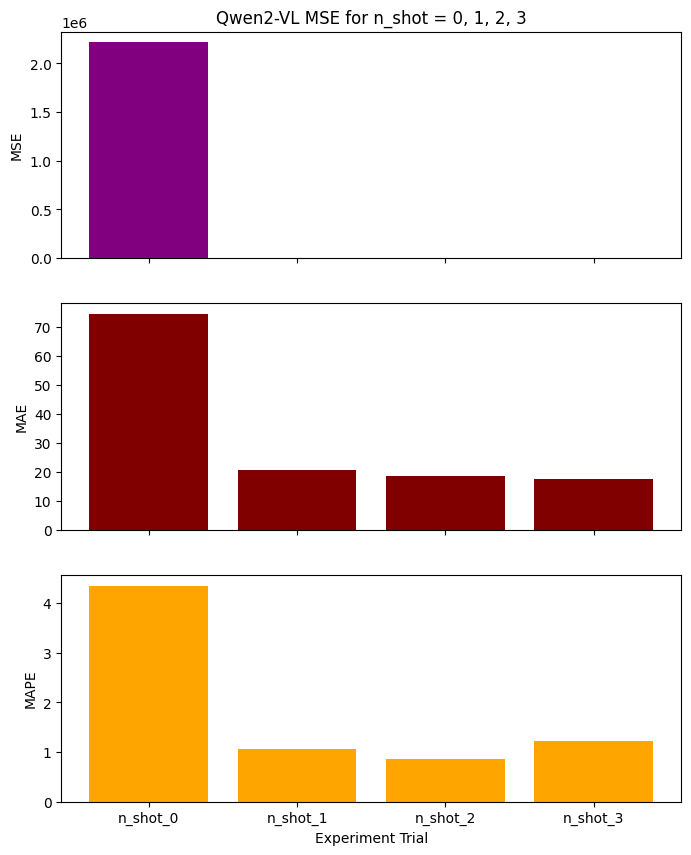

In [11]:
# Generate graphs
figs, axes = plt.subplots(3, figsize=(8,10))
axes[0].bar(x=[f'n_shot_{i}' for i in range(num_shots)], height=n_shot_MSE, color='purple')
axes[1].bar(x=[f'n_shot_{i}' for i in range(num_shots)], height=n_shot_MAE, color='maroon')
axes[2].bar(x=[f'n_shot_{i}' for i in range(num_shots)], height=n_shot_MAPE, color='orange')

axes[0].set_ylabel('MSE')
axes[1].set_ylabel('MAE')
axes[2].set_ylabel('MAPE')

axes[0].set_xticklabels([])
axes[1].set_xticklabels([])

axes[2].set_xlabel('Experiment Trial')
axes[0].set_title("Qwen2-VL MSE for n_shot = 0, 1, 2, 3")

In [12]:
# Major outliers present in the data
n_shot_df[n_shot_df['n_shot_0'] > 100000]

,image,num_nuclei,num_chromosomes,num_ecDNA,n_shot,n_shot_0,n_shot_1,n_shot_2,n_shot_3
210,1430.tif,0,23,36,"['{\n ""ecDNA"": 1234567890\n}', '{\n ""count...",1.234568e+09,0.0,0.0,5.0
414,1840.tif,1,0,0,"['{\n""ecDNA"": 1234567890\n}', '{""ecDNA_count"":...",1.234568e+09,0.0,1.0,8.0
588,218.tif,1,3,6,"['{\n ""ecDNA"": 1234567890\n}', '{\n""ecDNA"": {...",1.234568e+09,0.0,1.0,7.0
594,2193.tif,0,13,12,"['{\n ""ecDNA"": 1234567890\n}', '{\n""ecDNA"": 0...",1.234568e+09,0.0,0.0,0.0


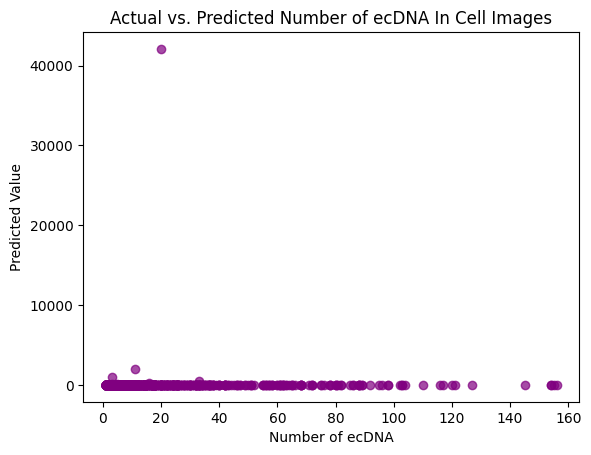

In [13]:
actual, predicted = filter_data(n_shot_df['num_ecDNA'], n_shot_df['n_shot_0'])
# Graph line plot
plt.scatter(actual, predicted, color='purple', alpha=0.7)
plt.xlabel('Number of ecDNA')
plt.ylabel('Predicted Value')
plt.title('Actual vs. Predicted Number of ecDNA In Cell Images')
plt.show()

### Temperature Adjustment

In [14]:
# Load data
temp_adj_df = pd.read_csv(temp_adj_path).drop(columns=['Unnamed: 0'])
temp_adj_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,temp_adj
0,0.tif,2,1,1,"['{\n ""ecDNA"": 0\n}', '{\n ""ecDNA"": 3\n}', '..."
1,1.tif,4,1,3,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 0\n}', '..."
2,10.tif,1,6,2,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 3\n}', '..."
3,1000.tif,3,4,2,"['{\n ""ecDNA"": 0\n}', '{\n ""ecDNA"": 3\n}', '..."
4,1001.tif,1,0,0,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 3\n}', '..."


In [15]:
# Parse results

temp_adj_MSE = []
temp_adj_MAE = []
temp_adj_MAPE = []

for i in range(len(temperatures)):
    temp_adj_df[f'temp_adj_{temperatures[i]}'] = temp_adj_df['temp_adj'].apply(lambda x: parse_result((x[1:-1].split(','))[i]))
    MSE, MAE, MAPE = calc_metrics(temp_adj_df['num_ecDNA'], temp_adj_df[f'temp_adj_{temperatures[i]}'])
    temp_adj_MSE.append(MSE)
    temp_adj_MAE.append(MAE)
    temp_adj_MAPE.append(MAPE)

temp_adj_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,temp_adj,temp_adj_0.2,temp_adj_0.3,temp_adj_0.5,temp_adj_0.8,temp_adj_0.9
0,0.tif,2,1,1,"['{\n ""ecDNA"": 0\n}', '{\n ""ecDNA"": 3\n}', '...",0.0,3.0,2.0,3.0,10000.0
1,1.tif,4,1,3,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 0\n}', '...",3.0,0.0,3.0,0.0,3.0
2,10.tif,1,6,2,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 3\n}', '...",3.0,3.0,3.0,0.0,2.0
3,1000.tif,3,4,2,"['{\n ""ecDNA"": 0\n}', '{\n ""ecDNA"": 3\n}', '...",0.0,3.0,0.0,0.0,3.0
4,1001.tif,1,0,0,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 3\n}', '...",3.0,3.0,3.0,2.0,10.0


In [16]:
temp_adj_MSE, temp_adj_MAE, temp_adj_MAPE

([895.9527363184079,
  900.8781094527363,
  910.0970149253732,
  249668.77334993772,
  258498.61221945137],
 [17.049751243781095,
  17.233830845771145,
  17.365671641791046,
  42.429638854296385,
  48.68703241895262],
 [0.8797886881689969,
  0.8980604396469799,
  0.8898696848466692,
  6.193237525747444,
  15.44513266706438])

Text(0.5, 1.0, 'Qwen2-VL Temperature Adjustment for temperatures = 0.2, 0.3, 0.5, 0.8, 0.9')

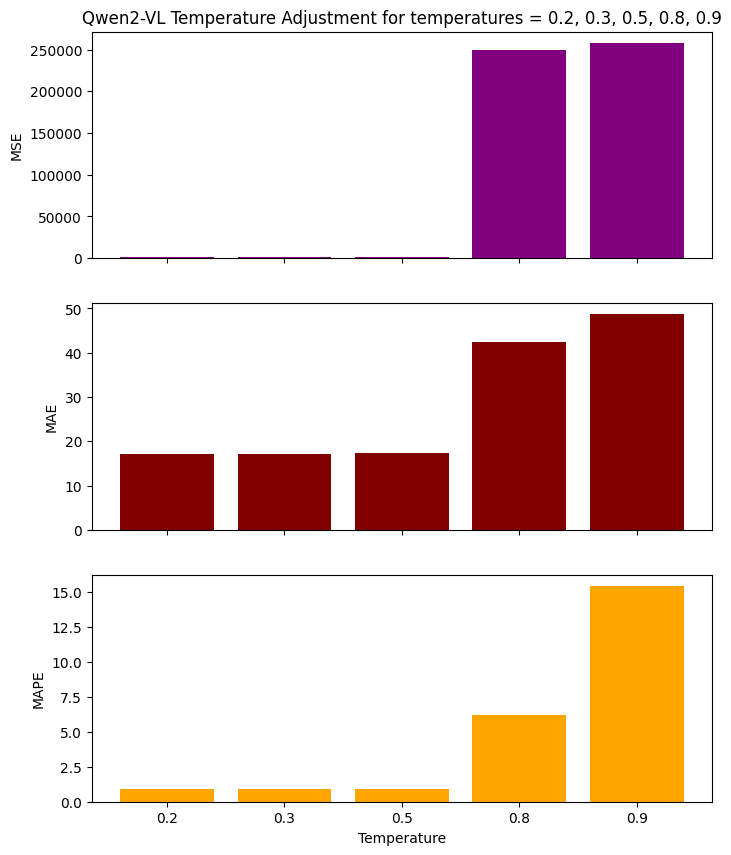

In [17]:
# Generate graphs
figs, axes = plt.subplots(3, figsize=(8,10))
axes[0].bar(x=[f'{temp}' for temp in temperatures], height=temp_adj_MSE, color='purple')
axes[1].bar(x=[f'{temp}' for temp in temperatures], height=temp_adj_MAE, color='maroon')
axes[2].bar(x=[f'{temp}' for temp in temperatures], height=temp_adj_MAPE, color='orange')

axes[0].set_ylabel('MSE')
axes[1].set_ylabel('MAE')
axes[2].set_ylabel('MAPE')

axes[0].set_xticklabels([])
axes[1].set_xticklabels([])

axes[2].set_xlabel('Temperature')
axes[0].set_title(f"Qwen2-VL Temperature Adjustment for temperatures = {str(temperatures)[1:-1]}")

### Multi-Layer Prompting

In [18]:
multi_layer_df = pd.read_csv(multi_layer_path)
multi_layer_df.head()

,Unnamed: 0,image,num_nuclei,num_chromosomes,num_ecDNA,multi_layer
0,0,0.tif,2,1,1,"{\n ""ecDNA_count"": 50\n}"
1,1,1.tif,4,1,3,"To determine the number of ecDNA in the image,..."
2,2,10.tif,1,6,2,"{\n ""ecDNA"": 0\n}"
3,3,1000.tif,3,4,2,{'ecDNA': 0}
4,4,1001.tif,1,0,0,"{\n""ecDNA"": 2\n}"


In [19]:
multi_layer_df['multi_layer'] = multi_layer_df['multi_layer'].apply(lambda x: parse_result(x))
multi_layer_df

,Unnamed: 0,image,num_nuclei,num_chromosomes,num_ecDNA,multi_layer
0,0,0.tif,2,1,1,50.0
1,1,1.tif,4,1,3,NaN
2,2,10.tif,1,6,2,0.0
3,3,1000.tif,3,4,2,0.0
4,4,1001.tif,1,0,0,2.0
...,...,...,...,...,...,...
1184,1184,992.tif,0,6,0,NaN
1185,1185,993.tif,0,18,3,0.0
1186,1186,994.tif,0,26,0,NaN
1187,1187,995.tif,0,17,5,3.0


In [20]:
multi_layer_MSE, multi_layer_MAE, multi_layer_MAPE = calc_metrics(multi_layer_df['num_ecDNA'], multi_layer_df['multi_layer'])

In [21]:
multi_layer_MSE, multi_layer_MAE, multi_layer_MAPE

(289804.5678776291, 73.79923518164436, 15.63950697870491)

### Result Aggregation

In [22]:
# Load data
agg_results_df = pd.read_csv(agg_results_path).drop(columns='Unnamed: 0')
agg_results_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,agg_results
0,0.tif,2,1,1,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 5\n}', '..."
1,1.tif,4,1,3,"['{\n ""ecDNA"": 3\n}', '{\n""ecDNA"": 10\n}', '{..."
2,10.tif,1,6,2,"['```json\n[{""ecDNA"": 3}]\n```', '```json\n{\n..."
3,1000.tif,3,4,2,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA_count"": 3\..."
4,1001.tif,1,0,0,"['```json\n{\n ""ecDNA"": 3\n}\n```', '```json\..."


In [23]:
agg_results_MSE = []
agg_results_MAE = []
agg_results_MAPE = []

for i in range(num_trials):
    agg_results_df[f'agg_results_{i+1}'] = agg_results_df['agg_results'].apply(lambda x: parse_result((x[1:-1].split(','))[i]))
    MSE, MAE, MAPE = calc_metrics(agg_results_df['num_ecDNA'], agg_results_df[f'agg_results_{i+1}'])
    agg_results_MSE.append(MSE)
    agg_results_MAE.append(MAE)
    agg_results_MAPE.append(MAPE)

agg_results_MSE.append(sum(agg_results_MSE)/num_trials)
agg_results_MAE.append(sum(agg_results_MAE)/num_trials)
agg_results_MAPE.append(sum(agg_results_MAPE)/num_trials)

agg_results_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,agg_results,agg_results_1,agg_results_2,agg_results_3,agg_results_4,agg_results_5
0,0.tif,2,1,1,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA"": 5\n}', '...",3.0,5.0,3.0,0.0,3.0
1,1.tif,4,1,3,"['{\n ""ecDNA"": 3\n}', '{\n""ecDNA"": 10\n}', '{...",3.0,10.0,10.0,3.0,0.0
2,10.tif,1,6,2,"['```json\n[{""ecDNA"": 3}]\n```', '```json\n{\n...",3.0,0.0,0.0,0.0,3.0
3,1000.tif,3,4,2,"['{\n ""ecDNA"": 3\n}', '{\n ""ecDNA_count"": 3\...",3.0,3.0,3.0,5.0,3.0
4,1001.tif,1,0,0,"['```json\n{\n ""ecDNA"": 3\n}\n```', '```json\...",3.0,0.0,1.0,4.0,3.0


In [24]:
agg_results_MSE, agg_results_MAE, agg_results_MAPE

([2265535.344139651,
  5691216.286792452,
  199391.25251256282,
  2785736.432330827,
  355455.08510638296,
  2259466.8801763756],
 [73.98753117206982,
  171.65283018867925,
  38.96356783919598,
  108.99874686716792,
  58.1063829787234,
  90.34181180916728],
 [9.383828599188744,
  32.70102182628125,
  17.86356841860888,
  39.43090403251836,
  12.432143113264527,
  22.362293197972352])

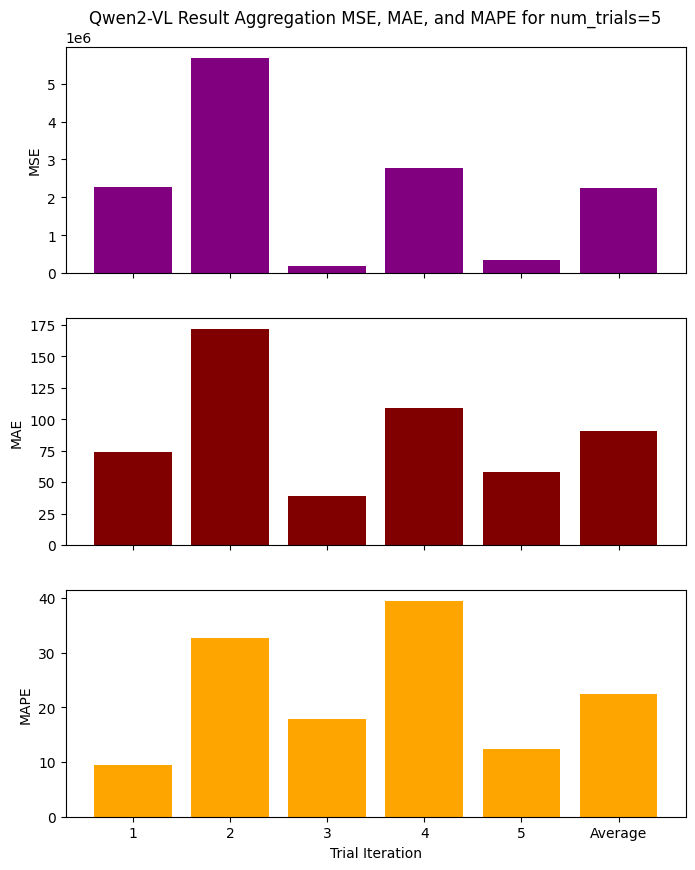

In [30]:
# Generate graphs
figs, axes = plt.subplots(3, figsize=(8,10))
axes[0].bar(x=[f'{i}' for i in [str(j) for j in range(1, num_trials+1)] + ['Average']], height=agg_results_MSE, color='purple')
axes[1].bar(x=[f'{i}' for i in [str(j) for j in range(1, num_trials+1)] + ['Average']], height=agg_results_MAE, color='maroon')
axes[2].bar(x=[f'{i}' for i in [str(j) for j in range(1, num_trials+1)] + ['Average']], height=agg_results_MAPE, color='orange')

axes[0].set_ylabel('MSE')
axes[1].set_ylabel('MAE')
axes[2].set_ylabel('MAPE')

axes[0].set_xticklabels([])
axes[1].set_xticklabels([])

axes[2].set_xlabel('Trial Iteration')
axes[0].set_title(f"Qwen2-VL Result Aggregation MSE, MAE, and MAPE for num_trials={num_trials}")
plt.show()

### Context Messages

In [39]:
context_messages_df = pd.read_csv(context_messages_path).drop(columns='Unnamed: 0')
context_messages_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,context_message
0,0.tif,2,1,1,"['{\n ""ecDNA_count"": 0\n}', '{\n ""count"": 2\..."
1,1.tif,4,1,3,"['{\n ""ecDNA"": 0\n}', '{\n ""count"": 2\n}', '..."
2,10.tif,1,6,2,"['{\n ""ecDNA"": 2\n}', '{\n ""count"": 0\n}', '..."
3,1000.tif,3,4,2,"['{""ecDNA"": 5}', '{\n ""count"": 0\n}', '{\n ""..."
4,1001.tif,1,0,0,"['{""ecDNA"": 2}', '{\n ""ecDNA"": 0\n}', '{\n ""..."


In [40]:
# Parse results

context_messages_MSE = []
context_messages_MAE = []
context_messages_MAPE = []

for i in range(len(context_messages)):
    context_messages_df[f'context_message_{i}'] = context_messages_df['context_message'].apply(lambda x: parse_result((x[1:-1].split(','))[i]))
    MSE, MAE, MAPE = calc_metrics(context_messages_df['num_ecDNA'], context_messages_df[f'context_message_{i}'])
    context_messages_MSE.append(MSE)
    context_messages_MAE.append(MAE)
    context_messages_MAPE.append(MAPE)

context_messages_df.head()

,image,num_nuclei,num_chromosomes,num_ecDNA,context_message,context_message_0,context_message_1,context_message_2
0,0.tif,2,1,1,"['{\n ""ecDNA_count"": 0\n}', '{\n ""count"": 2\...",0.0,2.0,2.0
1,1.tif,4,1,3,"['{\n ""ecDNA"": 0\n}', '{\n ""count"": 2\n}', '...",0.0,2.0,1.0
2,10.tif,1,6,2,"['{\n ""ecDNA"": 2\n}', '{\n ""count"": 0\n}', '...",2.0,0.0,2.0
3,1000.tif,3,4,2,"['{""ecDNA"": 5}', '{\n ""count"": 0\n}', '{\n ""...",5.0,0.0,0.0
4,1001.tif,1,0,0,"['{""ecDNA"": 2}', '{\n ""ecDNA"": 0\n}', '{\n ""...",2.0,0.0,1.0


In [41]:
context_messages_MSE, context_messages_MAE, context_messages_MAPE

([893.8594527363184, 936.8942786069651, 921.2412935323383],
 [17.006218905472636, 17.991293532338307, 17.587064676616915],
 [0.8517574642321918, 0.9477432182714075, 0.9014838799865948])

In [ ]:
# Generate graphs
figs, axes = plt.subplots(3, figsize=(8,10))
axes[0].bar(x=context_messages, height=context_messages_MSE, color='purple')
axes[1].bar(x=context_messages, height=context_messages_MAE, color='maroon')
axes[2].bar(x=context_messages, height=context_messages_MAPE, color='orange')

axes[0].set_ylabel('MSE')
axes[1].set_ylabel('MAE')
axes[2].set_ylabel('MAPE')

axes[0].set_xticklabels([])
axes[1].set_xticklabels([])

axes[2].set_xlabel('Trial Iteration')
axes[0].set_title(f"Qwen2-VL Result Aggregation MSE, MAE, and MAPE for num_trials={num_trials}")
plt.show()